# TP Embeddings
# Dataset: rideshare drivers YouTube titles

In [ ]:
!pip -q install gensim umap-learn

import re
import numpy as np
import pandas as pd

from google.colab import drive
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import umap
import gensim.downloader as api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.5 MB/s eta 0:00:00


In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


# 1. Load data

In [ ]:
drive.mount("/content/drive")
# TODO: change this path to your file location in Drive
CSV_PATH = "/content/drive/MyDrive/Embeddings_telecom/uberdrivers_videos_CLEAN.csv"

def read_csv_robust(path: str) -> pd.DataFrame:
    for sep in [";", ",", "\t"]:
        try:
            df0 = pd.read_csv(path, sep=sep)
            if df0.shape[1] >= 2:
                return df0
        except Exception:
            pass
    return pd.read_csv(path, sep=None, engine="python")

df = read_csv_robust(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

TEXT_COL = "title_clean" if "title_clean" in df.columns else "text_videotitle"
df[TEXT_COL] = df[TEXT_COL].astype(str).fillna("")

if "published_at" in df.columns:
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
if "video_viewcount" in df.columns:
    df["video_viewcount"] = pd.to_numeric(df["video_viewcount"], errors="coerce")

df["tokens"] = df[TEXT_COL].str.split()
df["n_tokens"] = df["tokens"].map(len)

print(df["n_tokens"].describe())
display(df[[TEXT_COL]].sample(10, random_state=0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (2682, 5)
Columns: ['video_id', 'published_at', 'channel_id', 'video_viewcount', 'title_clean']
count    2682.000000
mean        8.494034
std         3.244276
min         1.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        19.000000
Name: n_tokens, dtype: float64


,title_clean
317,why uber lyft drivers can't buy house uber ube...
385,ugh another left lane vigilante driving highwa...
2298,she canceled the ride and got into fight with ...
296,how to buy tesla for uber without going broke ...
686,uber thinks were dumb shorts
676,what want to say is passengers uber shorts
1845,bolt new facial recognition system
1836,bolt drivers what happens when you leave your ...
1832,huge factory fire near fort retail park and es...
958,what my community is about


# 3. Load pretrained GloVe vectors

In [ ]:
# Lighter than fastText, good for titles
wv = api.load("glove-wiki-gigaword-100")  # try 200/300 if you want
DIM = wv.vector_size
print("Loaded GloVe vectors. dim =", DIM)

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded GloVe vectors. dim = 100


# 4. Compute document embeddings (mean of word vectors)

In [ ]:
def doc_embedding_mean(tokens, wv):
    vecs = []
    for t in tokens:
        if t in wv:
            vecs.append(wv[t])
    if not vecs:
        return np.zeros(DIM, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

X = np.vstack([doc_embedding_mean(toks, wv) for toks in df["tokens"].tolist()])
X = normalize(X)

coverage = (np.linalg.norm(X, axis=1) > 0).mean()
print("X shape:", X.shape, "| coverage:", round(float(coverage), 3))

X shape: (2682, 100) | coverage: 0.998


#5. UMAP + clustering + inspect clusters

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


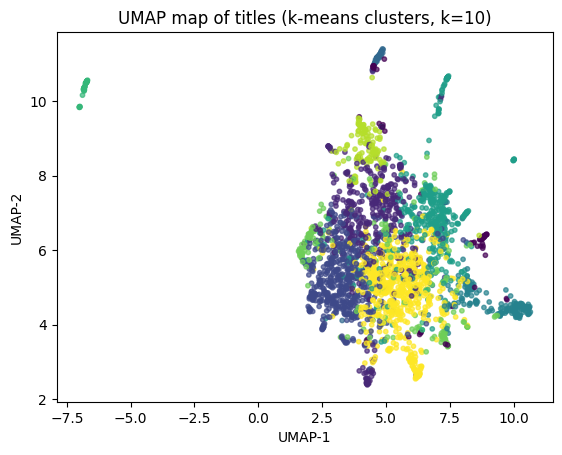


=== Cluster 0 — examples ===


,video_viewcount,published_at,channel_id,title_clean
766,242502,2024-12-02 01:34:41+00:00,UCTmiXQVRtmKbRiq57t-4KzA,karen slaps wendy's manager
2145,1850,2025-06-23 23:09:36+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,lilly ridesharereflections lyftdriver uberdriv...
2140,1789,2025-07-07 22:00:12+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,angela ridesharereflections lyftdriver uberdri...
2153,1727,2025-05-25 18:26:02+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,logan
2109,1677,2025-08-24 14:15:01+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tom cruise endorses rideshare reflections
2158,1598,2025-05-19 22:57:51+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,brittni
2138,1575,2025-07-10 00:19:23+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,ashley
2172,1500,2025-04-07 22:59:51+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tammi
2112,1261,2025-08-15 21:28:25+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,lebron endorses rideshare reflections
2168,1086,2025-04-15 22:03:02+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,rfk stadium



=== Cluster 1 — examples ===


,video_viewcount,published_at,channel_id,title_clean
733,12710153,2025-08-15 02:00:03+00:00,UCTmiXQVRtmKbRiq57t-4KzA,college kid mistakes cop car for uber
2571,332150,2025-09-16 18:47:45+00:00,UCZmazYa6TevH2ATxIq7cJKg,declined 184 uber rides to expose the algorithm
1684,197423,2016-11-07 17:57:55+00:00,UCIdEYx5MwpISAujYA6cwvWg,the best hours to drive for uber lyft
240,177673,2024-07-03 20:24:07+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,actual earnings of an uber driver in 2024
1672,154393,2017-01-21 16:45:48+00:00,UCIdEYx5MwpISAujYA6cwvWg,apps every uber driver should have
1674,139302,2017-01-09 19:18:33+00:00,UCIdEYx5MwpISAujYA6cwvWg,the best cars for uber lyft
1690,132445,2016-09-24 16:48:03+00:00,UCIdEYx5MwpISAujYA6cwvWg,one year of driving for uber lyft review
176,90496,2025-10-20 20:30:13+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,the worst way to drive uber
1693,87463,2016-09-08 00:58:05+00:00,UCIdEYx5MwpISAujYA6cwvWg,google maps vs waze which is better for uber l...
2437,85271,2023-01-22 19:07:55+00:00,UC6HwMfqtSqFKeaXLBg20p2g,is uber worth it



=== Cluster 2 — examples ===


...

,video_viewcount,published_at,channel_id,title_clean
1663,62531,2017-05-19 19:48:14+00:00,UCIdEYx5MwpISAujYA6cwvWg,tips on doordash grubhub featuring the ridesha...
764,17823,2024-12-26 05:27:10+00:00,UCTmiXQVRtmKbRiq57t-4KzA,the best camera dash cam dashcam
2519,14093,2025-12-14 13:18:29+00:00,UCZmazYa6TevH2ATxIq7cJKg,my uber winter mat setup
236,10914,2024-07-26 19:22:35+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,fun and awkward uber rides compilation
1667,10253,2017-03-01 20:03:28+00:00,UCIdEYx5MwpISAujYA6cwvWg,uber's ceo travis kalanick gets one-star rating
895,9297,2023-06-08 21:33:24+00:00,UC-gouXBSExpkaqZ9_c1Dd8g,my first st paul sandwich food foodie porkstea...
1746,5735,2025-01-16 22:07:36+00:00,UCyDEPurwbY1tb6PeUjYR6gg,seiko starry night melodies in motion wall clo...
767,5360,2024-11-27 15:33:57+00:00,UCTmiXQVRtmKbRiq57t-4KzA,vantrue n4 channel dashcam review
2522,5354,2025-12-10 19:38:12+00:00,UCZmazYa6TevH2ATxIq7cJKg,crazy long tesla supercharging lines
2193,4110,2025-01-22 23:35:22+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tesla mess



=== Cluster 8 — examples ===


,video_viewcount,published_at,channel_id,title_clean
724,326687,2025-09-07 22:52:06+00:00,UCTmiXQVRtmKbRiq57t-4KzA,zombie karen bites uber driver's neck
2453,44127,2021-05-15 16:00:32+00:00,UC6HwMfqtSqFKeaXLBg20p2g,uber car rental uber driver pay rideshare car ...
195,22389,2025-08-23 16:01:04+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,tesla door vs uber riders
2421,22128,2023-03-13 15:01:32+00:00,UC6HwMfqtSqFKeaXLBg20p2g,boston uber driver 40 surge uber lyft rideshar...
2317,17335,2024-08-26 22:00:45+00:00,UC-ivJVv3GtB_w_lpk_WQxHw,uber driver met lilli collins
1656,12329,2017-10-17 21:08:38+00:00,UCIdEYx5MwpISAujYA6cwvWg,my uber lyft vehicle setup
1262,9634,2022-05-20 01:57:36+00:00,UCaZiGrGjZhyYZmBTN5r11iw,yo bro it's uber pet not uber zoo
2569,8571,2025-09-17 10:03:56+00:00,UCZmazYa6TevH2ATxIq7cJKg,uber's hidden surge uber uberdriver
785,8419,2024-01-01 03:32:26+00:00,UCTmiXQVRtmKbRiq57t-4KzA,uber and lyft new year's eve driving newyearse...
2401,8097,2023-05-18 12:41:27+00:00,UC6HwMfqtSqFKeaXLBg20p2g,uber driver tips chasing surge uber rideshare ...



=== Cluster 9 — examples ===


,video_viewcount,published_at,channel_id,title_clean
1669,201919,2017-02-10 17:44:22+00:00,UCIdEYx5MwpISAujYA6cwvWg,driving for ubereats for the first time review
2454,181192,2021-05-14 18:00:09+00:00,UC6HwMfqtSqFKeaXLBg20p2g,is the uber car rental program worth it how to...
152,122456,2025-04-15 15:45:58+00:00,UCne_yPn6OKtwDXPDGDHSEOw,day in the life of an uber driver in 2025 full...
216,87956,2025-03-21 17:00:23+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,rider tries to order an uber next to the drive...
2678,87937,2022-09-19 03:16:11+00:00,UCYXWCyw3XGP5foPPAak34-Q,how to make lot of money driving for uber in 2023
1666,86416,2017-03-21 16:28:30+00:00,UCIdEYx5MwpISAujYA6cwvWg,taxes for uber lyft how much paid for 2016
124,84522,2025-08-08 15:20:29+00:00,UCne_yPn6OKtwDXPDGDHSEOw,is amazon flex worth it in 2025 my first day d...
2543,54816,2025-11-12 18:50:18+00:00,UCZmazYa6TevH2ATxIq7cJKg,uber's commercial auto insurance is broken ube...
241,51418,2024-06-28 19:30:03+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,rented tesla for uber was it worth it
164,28442,2025-11-26 21:13:06+00:00,UC7i3b9SF2vIeE-CgHR5jBIQ,stop sign optional


In [ ]:
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.10,
    n_components=2,
    random_state=42,
    metric="cosine",
)
Z = reducer.fit_transform(X)

K = 10  # try 6, 8, 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(X)

plt.figure()
plt.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.7, c=df["cluster"])
plt.title(f"UMAP map of titles (k-means clusters, k={K})")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

def show_cluster_examples(df, c, n=12):
    d = df[df["cluster"] == c].copy()
    if "video_viewcount" in d.columns and d["video_viewcount"].notna().any():
        d = d.sort_values("video_viewcount", ascending=False)
    cols = [col for col in ["video_viewcount", "published_at", "channel_id", TEXT_COL] if col in d.columns]
    return d[cols].head(n)

for c in range(K):
    print(f"\n=== Cluster {c} — examples ===")
    display(show_cluster_examples(df, c, n=12))

#6. Expertise score (seeds + cosine similarity)

Seed indices: [2673, 224, 2454, 240, 152, 2678, 1663, 175, 1683, 486, 1659, 1678]


,title_clean,video_viewcount
2673,uber drivers must do this trick to make more m...,597559
224,how to trick the uber algorithm to earn more m...,270965
2454,is the uber car rental program worth it how to...,181192
240,actual earnings of an uber driver in 2024,177673
152,day in the life of an uber driver in 2025 full...,122456
2678,how to make lot of money driving for uber in 2023,87937
1663,tips on doordash grubhub featuring the ridesha...,62531
175,10 tricks to earn more driving uber and lyft,62046
1683,10 tips for new uber lyft drivers,55371
486,how much made in my first week as an uber driv...,47765


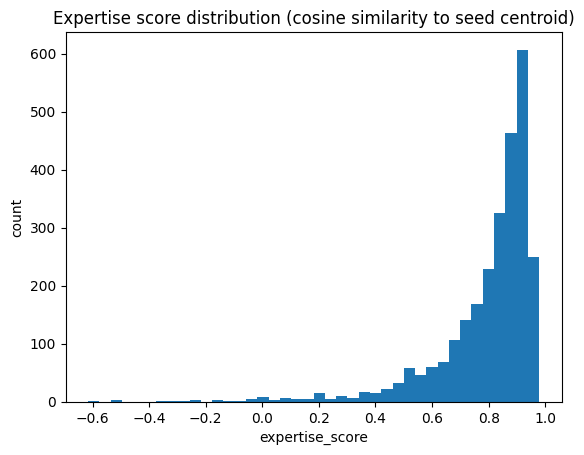


--- TOP expertise_score ---


,expertise_score,video_viewcount,published_at,channel_id,title_clean
2678,0.978298,87937,2022-09-19 03:16:11+00:00,UCYXWCyw3XGP5foPPAak34-Q,how to make lot of money driving for uber in 2023
2433,0.975896,19507,2023-02-02 18:36:26+00:00,UC6HwMfqtSqFKeaXLBg20p2g,tips for better driving with lyft how to make ...
782,0.975877,10875,2024-02-06 02:15:21+00:00,UCTmiXQVRtmKbRiq57t-4KzA,driving for uber and lyft for week how much made
1575,0.974775,204,2025-06-12 00:35:28+00:00,UC57d9r_n61Vhyxq1tllrmAg,new drivers can this uber driver make 12 as th...
1606,0.974775,609,2025-01-03 12:15:00+00:00,UC57d9r_n61Vhyxq1tllrmAg,new drivers can this uber driver make 12 as th...
2666,0.974309,4733,2023-04-01 02:06:37+00:00,UCYXWCyw3XGP5foPPAak34-Q,uber and lyft drivers must turn off this featu...
2483,0.972910,412,2020-10-26 15:22:25+00:00,UC6HwMfqtSqFKeaXLBg20p2g,uber driver how to make money from home
479,0.972641,3309,2025-11-17 23:18:50+00:00,UC1baUMIHVNrw0_Qxp4slInw,day from 2000 in one week challenge driving fo...
1956,0.971909,1958,2025-11-14 14:19:01+00:00,UCGT7T2ngAjrsTk3PI8o85tA,uber drivers this is how to beat the algo make...
2651,0.971320,4380,2023-09-27 00:44:55+00:00,UCYXWCyw3XGP5foPPAak34-Q,uber just cut another pay with the boost activ...



--- BOTTOM expertise_score ---


,expertise_score,video_viewcount,published_at,channel_id,title_clean
53,-0.615431,16,2024-09-23 13:04:44+00:00,UCR5naNLGZiDw9d4xuxXaXEA,capcut lyftdriver truckdriver rideshare
2161,-0.507436,373,2025-05-07 22:30:15+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,cyndy
2099,-0.504523,322,2025-09-08 22:30:00+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,lesly
2102,-0.349349,558,2025-09-03 01:34:14+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tamera
2163,-0.334511,631,2025-05-05 23:00:28+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,gabbi
88,-0.283629,36,2024-05-01 15:34:42+00:00,UCR5naNLGZiDw9d4xuxXaXEA,rideshare vlogs gopro videos rideshare uber lyft
85,-0.247305,85,2024-05-10 04:04:11+00:00,UCR5naNLGZiDw9d4xuxXaXEA,uber lyft rideshare driver uberdriver rideshar...
2172,-0.246506,1500,2025-04-07 22:59:51+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tammi
2117,-0.163197,308,2025-08-12 00:32:33+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,ciaran
2171,-0.162841,288,2025-04-09 22:00:13+00:00,UCd3w_zDVDZCaX9ajTQSRgTA,tarek



Expertise score by cluster:


,mean,median,count
cluster,,,
2,0.887116,0.903376,554
9,0.879459,0.900965,629
1,0.864155,0.878075,427
5,0.839811,0.853981,405
4,0.697587,0.719847,199
7,0.645003,0.659671,191
8,0.555705,0.589229,128
3,0.554785,0.564779,48
6,0.493435,0.508602,44


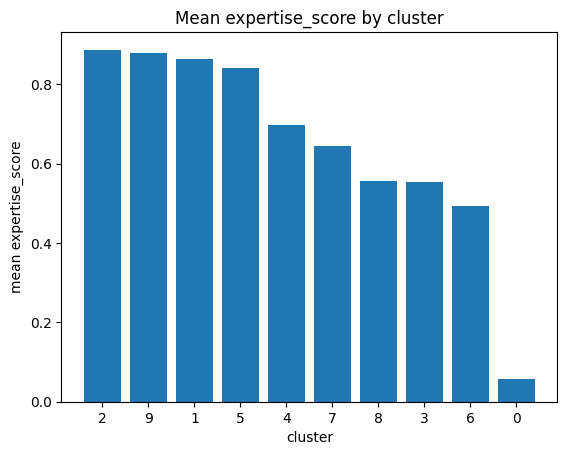

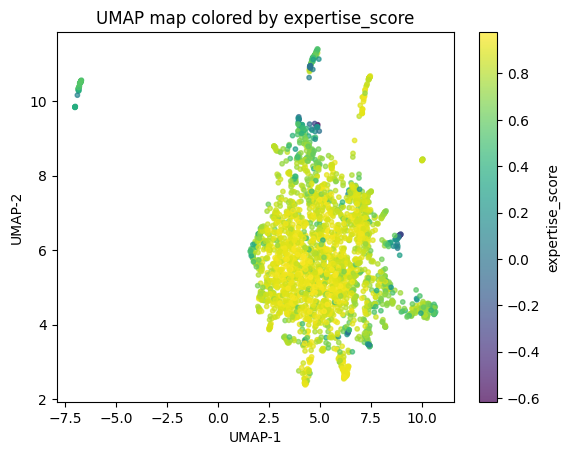

In [ ]:
# Option A (corrigé): propose seed candidates using simple patterns
EXPERTISE_PATTERNS = [
    r"\bhow to\b", r"\btips?\b", r"\btricks?\b", r"\bguide\b", r"\btutorial\b",
    r"\bstrategy\b", r"\bexplained\b", r"\bbeginners?\b", r"\bstep by step\b",
    r"\bmake money\b", r"\bearni?ngs?\b", r"\bmaximize\b", r"\boptimization\b",
]
expert_re = re.compile("|".join(EXPERTISE_PATTERNS), flags=re.IGNORECASE)
df["is_seed_candidate"] = df[TEXT_COL].str.contains(expert_re, na=False)

N_SEEDS = 12
seed_df = df[df["is_seed_candidate"]].copy()

if len(seed_df) == 0:
    print("No seed candidates found with the heuristic. Define seeds manually (Option B).")
    seeds = []
else:
    if "video_viewcount" in seed_df.columns and seed_df["video_viewcount"].notna().any():
        seed_df = seed_df.sort_values("video_viewcount", ascending=False)
    else:
        seed_df = seed_df.sort_values("n_tokens", ascending=False)
    seeds = seed_df.head(N_SEEDS).index.tolist()

print("Seed indices:", seeds)
if seeds:
    display(df.loc[seeds, [TEXT_COL] + (["video_viewcount"] if "video_viewcount" in df.columns else [])])

# Option B (manual seeds):
# seeds = [123, 456, 789, ...]  # uncomment and set manually if needed

if len(seeds) == 0:
    raise RuntimeError("No seeds defined. Please set manual seed indices and rerun this block.")

seed_centroid = normalize(X[seeds].mean(axis=0, keepdims=True))
df["expertise_score"] = cosine_similarity(X, seed_centroid).ravel()

plt.figure()
plt.hist(df["expertise_score"], bins=40)
plt.title("Expertise score distribution (cosine similarity to seed centroid)")
plt.xlabel("expertise_score"); plt.ylabel("count")
plt.show()

def show_score_examples(df, n=12):
    cols = [col for col in ["expertise_score", "video_viewcount", "published_at", "channel_id", TEXT_COL] if col in df.columns]
    print("\n--- TOP expertise_score ---")
    display(df.sort_values("expertise_score", ascending=False)[cols].head(n))
    print("\n--- BOTTOM expertise_score ---")
    display(df.sort_values("expertise_score", ascending=True)[cols].head(n))

show_score_examples(df, n=12)

cluster_score = df.groupby("cluster")["expertise_score"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print("\nExpertise score by cluster:")
display(cluster_score)

plt.figure()
plt.bar(cluster_score.index.astype(str), cluster_score["mean"].values)
plt.title("Mean expertise_score by cluster")
plt.xlabel("cluster"); plt.ylabel("mean expertise_score")
plt.show()

plt.figure()
plt.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.7, c=df["expertise_score"])
plt.title("UMAP map colored by expertise_score")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.colorbar(label="expertise_score")
plt.show()

#7. Optional: expertise vs visibility


,mean,median,count
expertise_top20,,,
0,6.826557,6.814543,2145
1,6.727682,6.951772,537


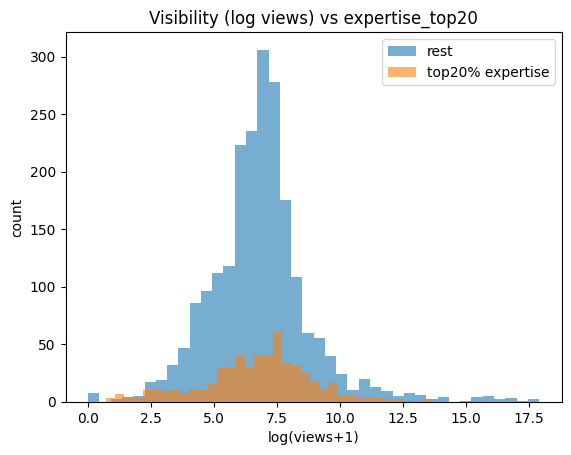

Saved: /content/drive/MyDrive/Embeddings_telecom/uberdrivers_titles_glove_tp_output.csv


In [ ]:
# Optional analysis: expertise vs visibility
if "video_viewcount" in df.columns and df["video_viewcount"].notna().any():
    df["log_views"] = np.log1p(df["video_viewcount"].fillna(0))
    thr = df["expertise_score"].quantile(0.80)
    df["expertise_top20"] = (df["expertise_score"] >= thr).astype(int)

    display(df.groupby("expertise_top20")["log_views"].agg(["mean", "median", "count"]))

    plt.figure()
    plt.hist(df.loc[df["expertise_top20"] == 0, "log_views"], bins=40, alpha=0.6, label="rest")
    plt.hist(df.loc[df["expertise_top20"] == 1, "log_views"], bins=40, alpha=0.6, label="top20% expertise")
    plt.title("Visibility (log views) vs expertise_top20")
    plt.xlabel("log(views+1)"); plt.ylabel("count")
    plt.legend()
    plt.show()

# Save outputs back to Drive
OUT_PATH = "/content/drive/MyDrive/Embeddings_telecom/uberdrivers_titles_glove_tp_output.csv"
df.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("Saved:", OUT_PATH)
